# Beyond BLAST

In [2]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 0;
using Pkg
Pkg.activate("blast_code"; io=devnull)
Pkg.resolve(; io=devnull)
Pkg.instantiate(; io=devnull)

using Base.Threads
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using FFTW
using FastTransforms
using Dates
using TOML
using Plots
using QuadGK
using LaTeXStrings
using Tullio
using StaticArrays
using LoopVectorization
using LinearAlgebra
using Unitful
using Revise
using SpecialFunctions
using DifferentialEquations
using Cosmology
using NumericalIntegration
using CSV
using DataFrames
using JSON

include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
using .Blast
using .blast_tutorials;

[ Info: Precompiling DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0]
Precompiling packages...
   2148.9 ms  ✓ DataInterpolations → DataInterpolationsChainRulesCoreExt
  1 dependency successfully precompiled in 3 seconds. 37 already precompiled.
[ Info: Precompiling DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd]
┌ Warning: Module DataInterpolations with build ID fafbfcfd-f666-e717-e5a0-7caade2384cb is missing from the cache.
│ This may mean DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2022
[ Info: Skipping precompilation since __precompile__(false). Importing DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd].
Precompiling packages...
    580.0 ms  ✓ FastChebInterp
  1 dependency successfully precompiled in 1 seconds. 18 already precompiled.
[ Info: Precompiling FastChebInterp [cf66c380-9a80-432c-aff8-4f9c79c0bdde]
Precompi

In [3]:
include("blast_code/src/galaxy_galaxy.jl")
#include("blast_code/src/galaxy_shear.jl")
include("blast_code/src/shear_shear.jl")
using .galaxy_galaxy
#using .galaxy_shear
using .shear_shear

In [82]:
timestamp = Dates.format(now(), "yyyy_mm_dd_HHMMSS")
output_dir = "out/runs/run_$timestamp"
plot_subdir = joinpath(output_dir, "plots")
quantity_subdir = joinpath(output_dir, "quantities")
mkpath(output_dir)
mkpath(plot_subdir)
mkpath(quantity_subdir)
println("Folders in place: ", output_dir, ", ", plot_subdir, " and ", quantity_subdir)

Folders in place: out/runs/run_2026_06_15_171150, out/runs/run_2026_06_15_171150/plots and out/runs/run_2026_06_15_171150/quantities


### Getting background quantities:

redshift $z$, comoving distance $\chi(z)$

In [83]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
χ_b = npzread("blast_code/data/background/chi.npy") # array 
# using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b); # z(χ)
chi_of_z = DataInterpolations.AkimaInterpolation(χ_b, z_b); # χ(z)

#### Setting parameters

In [85]:
cosmo = Blast.FlatΛCDM()
n_chi = 96                                            # Number of comoving distance points
x_range = LinRange(26, 7000, n_chi)
z_range = z_of_χ.(x_range)
#ℓ = Blast.ℓ
ℓ = LinRange(2, 200, 100)
x_min = minimum(x_range)                              # minimum comoving distance [Mpc/h]
x_max = maximum(x_range)                              # maximum comoving distance [Mpc/h]
chi = LinRange(x_min, x_max, n_chi)                   # array of comoving distances [Mpc/h]
zed = z_of_χ.(chi)                                    # array of redshifts corresponding to the comoving distances
n_z = length(zed)
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")
z_n5k = n5k_bins["z_cl"]
zmin = minimum(z_n5k)                                 # minimum redshift
zmax = maximum(z_n5k)                                 # maximum redshift
kmax = 200/13                                         # maximum wavenumber (small scales) [h/Mpc]
kmin = 2.5/x_max                                      # minimum wavenumber (large scales) [h/Mpc]
n_cheb = 119                                          # number of Chebyshev nodes 
β = 2                                                 # exponent depending on the probe: 0 for Galaxy - Shear, 2 for Galaxy - Galaxy, -2 for Shear - Shear
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax)) # number of Chebyshev "points"
N = 2^15+1;

In [86]:
shear_prefac_W = shear_shear.shear_prefactor(x_range, z_range, cosmo; output_dir=output_dir);
shear_prefac_W_cheb = shear_shear.shear_prefactor_cheb(zmin, zmax, n_cheb, z_range, shear_prefac_W; output_dir=output_dir);
cheb_coeff_shear = shear_shear.compute_prefactor_chebcoeffs(shear_prefac_W_cheb; output_dir=output_dir);

Plot saved: out/runs/run_2026_06_15_171150/plots/chi_vs_z_shear.png
Plot saved: out/runs/run_2026_06_15_171150/plots/nz_shear.png
Wrote W(z) shear prefactor on Chebyshev grid to: out/runs/run_2026_06_15_171150/quantities/prefac_on_cheb_shear.npy
Wrote W(z) Chebyshev coefficients to: out/runs/run_2026_06_15_171150/quantities/W_cheb_coeff_shear.npy


Defining the kernel/window function for a galaxy probe: the window function is \
\
$W(z) = n(z) \chi(z)^2 b(z) D(z) $ \
\
where \
\
$n(z) = (\frac{z}{z_0})^{\alpha} exp[{-(\frac{z}{z_0})^{\beta}}] $, with $\alpha = 2$ and $\beta = 1.5$ \
\
$b(z) = b_0 \sqrt{1+z} $ and $b_0 = 1$ \
\
$D(z) = \frac{D(z)^{unnorm}}{D(0)^{unnorm}}$, with $D(z)^{unnorm} = E(z) \int_0^{\infty} dz' \frac{1+z'}{E(z')^3} $ 

In [87]:
gal_prefact_W, bias, growth, inv_Hubble, nz = galaxy_galaxy.galaxy_prefactor(x_range, z_range, cosmo; output_dir=output_dir);
gal_prefact_W_cheb = galaxy_galaxy.galaxy_prefactor_cheb(zmin, zmax, n_cheb, z_range, chi, bias, growth, inv_Hubble, nz; output_dir=output_dir);
cheb_coeff_gal = galaxy_galaxy.compute_prefactor_chebcoeffs(gal_prefact_W_cheb; output_dir=output_dir);

Plot saved: out/runs/run_2026_06_15_171150/plots/chi_vs_z.png
Plot saved: out/runs/run_2026_06_15_171150/plots/bias.png
Plot saved: out/runs/run_2026_06_15_171150/plots/growth.png
Plot saved: out/runs/run_2026_06_15_171150/plots/inv_hubble.png
Plot saved: out/runs/run_2026_06_15_171150/plots/nz.png
Plot saved: out/runs/run_2026_06_15_171150/plots/Wz.png
Plot saved: out/runs/run_2026_06_15_171150/plots/normalized_quantities_galaxy.png
Wrote W(z) prefactor to: out/runs/run_2026_06_15_171150/quantities/prefac_galaxy.npy
Wrote W(z) prefactor on Chebyshev grid to: out/runs/run_2026_06_15_171150/quantities/prefac_on_cheb_galaxy.npy
Wrote W(z) Chebyshev coefficients to: out/runs/run_2026_06_15_171150/quantities/W_cheb_coeff_galaxy.npy


In [88]:
println("Size of cheb_coeffs must be the same for shear and galaxy")
println("size of cheb_coeff_shear: ", size(cheb_coeff_shear))
println("size of cheb_coeff_gal: ", size(cheb_coeff_gal))

Size of cheb_coeffs must be the same for shear and galaxy
size of cheb_coeff_shear: (119,)
size of cheb_coeff_gal: (119,)


In [89]:
W_tilde = zeros(length(ℓ), length(z_range), length(z_range), n_cheb)
for i in eachindex(ℓ)
    W_tilde[i,:,:,:] = Blast.compute_W_tilde(ℓ[i], zmin, zmax, kmin, kmax, z_range, n_cheb - 1, N, chi_of_z)
    println("Finished computing W_tilde for ℓ = $(ℓ[i]) at $(Dates.now())")
end

Finished computing W_tilde for ℓ = 2.0 at 2026-06-15T17:12:20.406
Finished computing W_tilde for ℓ = 4.0 at 2026-06-15T17:12:42.408
Finished computing W_tilde for ℓ = 6.0 at 2026-06-15T17:13:05.097
Finished computing W_tilde for ℓ = 8.0 at 2026-06-15T17:13:27.164
Finished computing W_tilde for ℓ = 10.0 at 2026-06-15T17:13:49.165
Finished computing W_tilde for ℓ = 12.0 at 2026-06-15T17:14:11.422
Finished computing W_tilde for ℓ = 14.0 at 2026-06-15T17:14:33.807
Finished computing W_tilde for ℓ = 15.999999999999998 at 2026-06-15T17:14:55.941
Finished computing W_tilde for ℓ = 18.0 at 2026-06-15T17:15:18.567
Finished computing W_tilde for ℓ = 20.0 at 2026-06-15T17:15:43.679
Finished computing W_tilde for ℓ = 22.0 at 2026-06-15T17:16:08.514
Finished computing W_tilde for ℓ = 24.0 at 2026-06-15T17:23:25.879
Finished computing W_tilde for ℓ = 26.0 at 2026-06-15T17:23:57.878
Finished computing W_tilde for ℓ = 28.000000000000004 at 2026-06-15T17:25:28.773
Finished computing W_tilde for ℓ = 29.

In [90]:
npzwrite(joinpath(output_dir, "W_tilde.npy"), W_tilde)

In [91]:
println("Size of W_tilde: ", size(W_tilde))

Size of W_tilde: (100, 96, 96, 119)


In [92]:
npzwrite(joinpath(output_dir, "cheb_coeff_shear.npy"), cheb_coeff_shear)
npzwrite(joinpath(output_dir, "cheb_coeff_gal.npy"), cheb_coeff_gal)

In [93]:
@tullio W_final_gal[i, j, k] := W_tilde[i, j, k, l] * cheb_coeff_gal[l];
@tullio W_final_shear[i, j, k] := W_tilde[i, j, k, l] * cheb_coeff_shear[l];

In [94]:
npzwrite(joinpath(output_dir, "W_final_gal.npy"), W_final_gal)
npzwrite(joinpath(output_dir, "W_final_shear.npy"), W_final_shear)

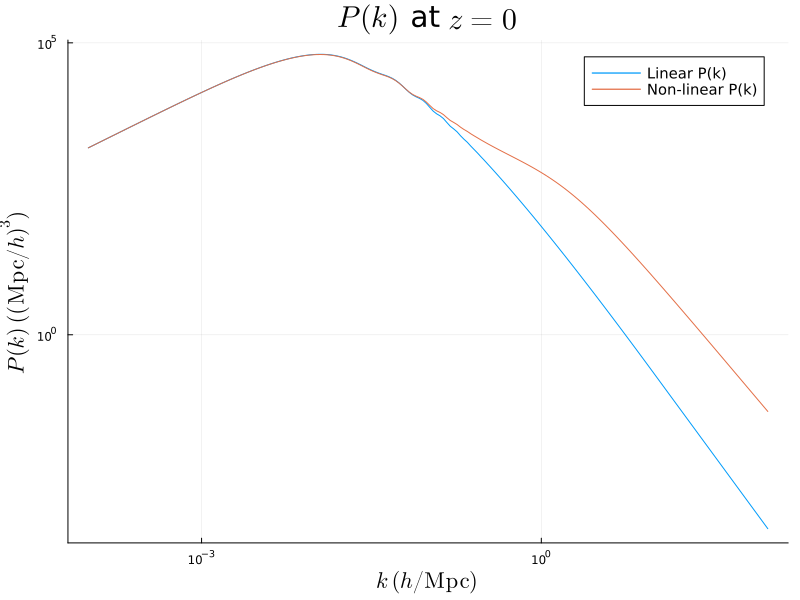

In [95]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];

# println("Dimension of k points: ", size(k)[1])
# println("Dimension of Pklin: ", size(Pklin)[1])
# println("Dimension of Pknonlin: ", size(Pknonlin)[1])

#Interpolating the power spectrum
#Linear P(k)
# y has the same length as k, and is a logarithmic range from log10(first(k)) to log10(last(k))
y = LinRange(log10(first(k)),log10(last(k)), length(k))
# x has the same length as z, and is a linear range from first(z) to last(z)
x = LinRange(first(z), last(z), length(z))

# this creates an interpolation of the linear P(k) data. 
# the interpolatio is in log space because P(k) changes by many order or magnitude
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
# this scales the interpolation to the x and y ranges defined above, 
# so that we can evaluate it at any (z, log10(k)) within those ranges
InterpPmm = scale(InterpPmm, (x, y))
# this allows us to extrapolate the interpolation outside of the defined x and y ranges
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())

#Non-linear P(k) - similar to the linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())

#Callables: these functions take in k, χ1, and χ2, 
# and return the square root of the product of the P(k) evaluated at those points.
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));

plot(k, power_spectrum.(k, 1000.0, 1000.0), 
     label="Linear P(k)", 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$P(k)$ at $z=0$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
     labelfontsize=15)
plot!(k, power_spectrum_nl.(k, 1000.0, 1000.0), 
      label="Non-linear P(k)", 
      xscale=:log10, 
      yscale=:log10,
      size=(800,600),
      legendfontsize=10)

In [96]:
Nz = n_chi
k_grid = Blast.get_clencurt_grid(kmin, kmax, Nz)
kp_grid = Blast.get_clencurt_grid(kmin, kmax, Nz) # for the second integral in the double Bessel case
kpp_grid = Blast.get_clencurt_grid(kmin, kmax, Nz); # for the third integral in the double Bessel case

In [97]:
Pk_grid = power_spectrum_nl.(k_grid, first(z), last(z));
Nk = length(k_grid)
Nℓ = length(ℓ)
w_k = FastTransforms.clenshawcurtisweights(
      FastTransforms.chebyshevmoments1(Float64, Nk)) * (kmax - kmin) / 2
wktot_gg = @. (2/pi) * w_k * k_grid^2 * kp_grid * kpp_grid * Pk_grid;
wktot_ss = @. (2/pi) * w_k * k_grid^(-2) * kp_grid * kpp_grid * Pk_grid;
wktot_sg = @. (2/pi) * w_k * kp_grid * kpp_grid * Pk_grid;
ell_prefactor_shear = @. ((ℓ+2)*(ℓ+1)*ℓ*(ℓ-1));
ell_prefactor_shear_gal = @. sqrt(((ℓ+2)*(ℓ+1)*ℓ*(ℓ-1)) );

In [98]:
println("size of wktot (gal): ", size(wktot_gg))
println("size of wktot (shear): ", size(wktot_ss))
println("size of W_final_gal: ", size(W_final_gal))
println("size of W_final_shear: ", size(W_final_shear))
println("size of ell_prefactor_shear: ", size(ell_prefactor_shear))
println("size of ell_prefactor_shear_gal: ", size(ell_prefactor_shear_gal))

size of wktot (gal): (96,)
size of wktot (shear): (96,)
size of W_final_gal: (100, 96, 96)
size of W_final_shear: (100, 96, 96)
size of ell_prefactor_shear: (100,)
size of ell_prefactor_shear_gal: (100,)


In [99]:
S_lkk_gg = zeros(Float64, size(W_final_gal, 3), size(W_final_gal, 3), length(ℓ))
@tullio S_lkk_gg[kp, kpp, li] := wktot_gg[k] * W_final_gal[li, k, kp] * W_final_gal[li, kp, kpp];
S_lkk_ss = zeros(Float64, size(W_final_shear, 3), size(W_final_shear, 3), length(ℓ))
@tullio S_lkk_ss[kp, kpp, li] := ell_prefactor_shear[li] * wktot_ss[k] * W_final_shear[li, k, kp] * W_final_shear[li, kp, kpp]
S_lkk_gs = zeros(Float64, size(W_final_shear, 3), size(W_final_gal, 3), length(ℓ))
@tullio S_lkk_gs[kp, kpp, li] := ell_prefactor_shear_gal[li] * wktot_sg[k] * W_final_shear[li, k, kp] * W_final_gal[li, kp, kpp];

In [100]:
npzwrite(joinpath(output_dir, "S_lkk_gg.npy"), S_lkk_gg)
npzwrite(joinpath(output_dir, "S_lkk_ss.npy"), S_lkk_ss)
npzwrite(joinpath(output_dir, "S_lkk_gs.npy"), S_lkk_gs);

In [101]:
println("Size of S_l (kp, kpp) (gal-gal):  ", size(S_lkk_gg))
println("Size of S_l (kp, kpp) (shear-shear):  ", size(S_lkk_ss))
println("Size of S_l (kp, kpp) (shear-gal):  ", size(S_lkk_gs))

Size of S_l (kp, kpp) (gal-gal):  (96, 96, 100)
Size of S_l (kp, kpp) (shear-shear):  (96, 96, 100)
Size of S_l (kp, kpp) (shear-gal):  (96, 96, 100)


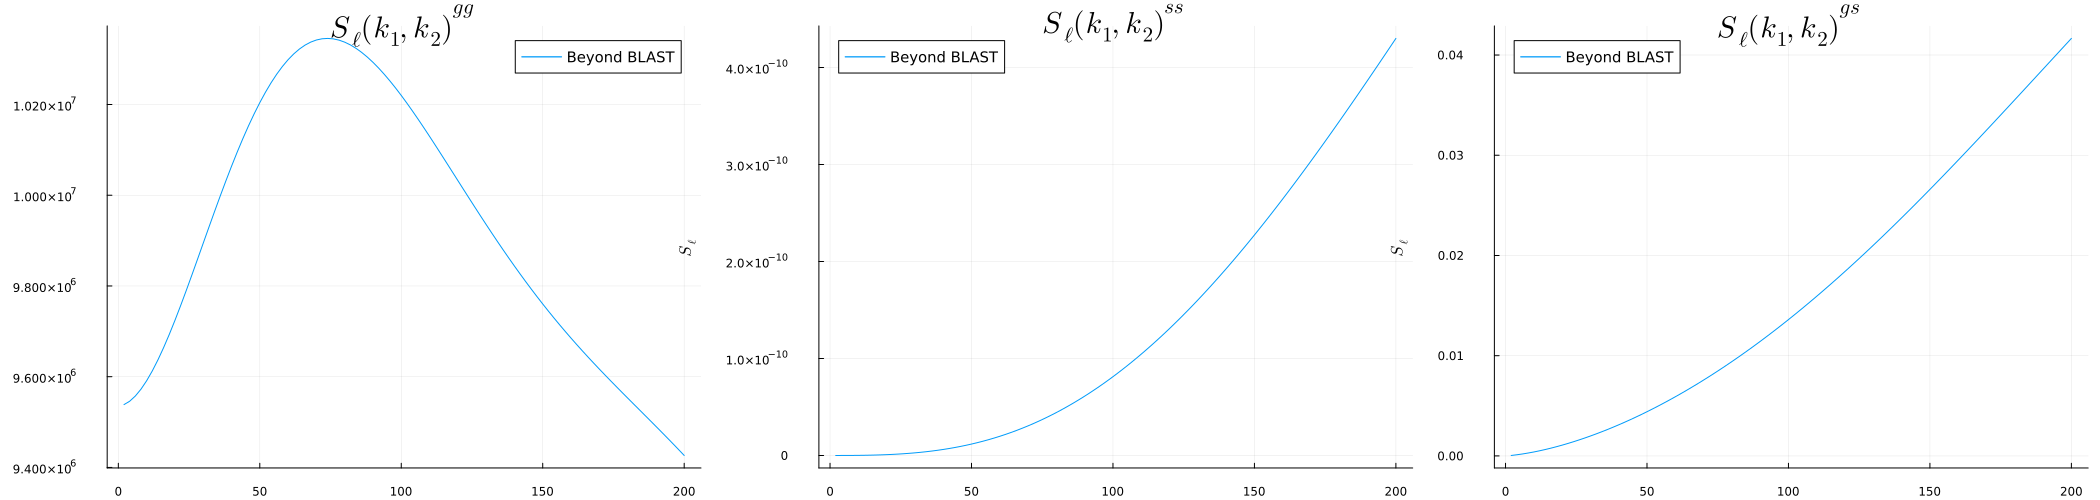

In [102]:
# plot
i = 2
j = 2
p1 =  plot(ℓ, S_lkk_gg[i,j,:], label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell(k_1, k_2)^{gg}")
p2 =  plot(ℓ, S_lkk_ss[i,j,:], label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell(k_1, k_2)^{ss}")
p3 =  plot(ℓ, S_lkk_gs[i,j,:], label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell(k_1, k_2)^{gs}")

plot(p1, p2, p3, layout = (1, 3), size=(2100, 500), titlefontsize=20, legendfontsize=10)

In [104]:
S_l_gg = zeros(Float64, length(ℓ))
@tullio S_l_gg[li] := w_k[kp] * w_k[kpp] * S_lkk_gg[kp, kpp, li];
S_l_ss = zeros(Float64, length(ℓ))
@tullio S_l_ss[li] := w_k[kp] * w_k[kpp] * S_lkk_ss[kp, kpp, li];
S_l_gs = zeros(Float64, length(ℓ))
@tullio S_l_gs[li] := w_k[kp] * w_k[kpp] * S_lkk_gs[kp, kpp, li];

In [105]:
npzwrite(joinpath(output_dir, "S_l_gg.npy"), S_l_gg)
npzwrite(joinpath(output_dir, "S_l_ss.npy"), S_l_ss)
npzwrite(joinpath(output_dir, "S_l_gs.npy"), S_l_gs);

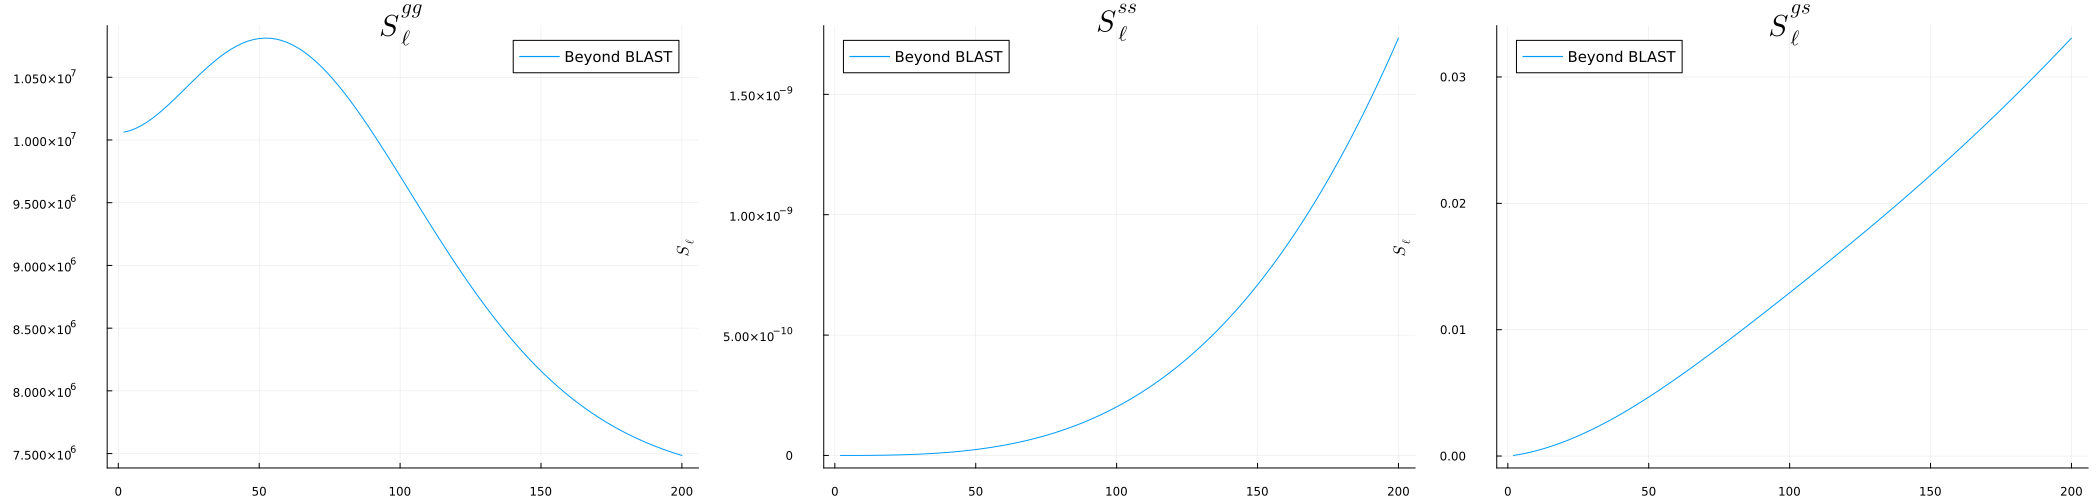

In [119]:
# plot
p1 =  plot(ℓ, S_l_gg, label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell^{gg}", size = (1400,800))
savefig(joinpath(output_dir, "plots/S_l_plot_gg.png"))
p2 =  plot(ℓ, S_l_ss, label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell^{ss}", size = (1400,800))
savefig(joinpath(output_dir, "plots/S_l_plot_ss.png"))
p3 =  plot(ℓ, S_l_gs, label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell^{gs}", size = (1400,800))
savefig(joinpath(output_dir, "plots/S_l_plot_gs.png"))
plot(p1, p2, p3, layout = (1, 3), size=(2100, 500), titlefontsize=20, legendfontsize=10)

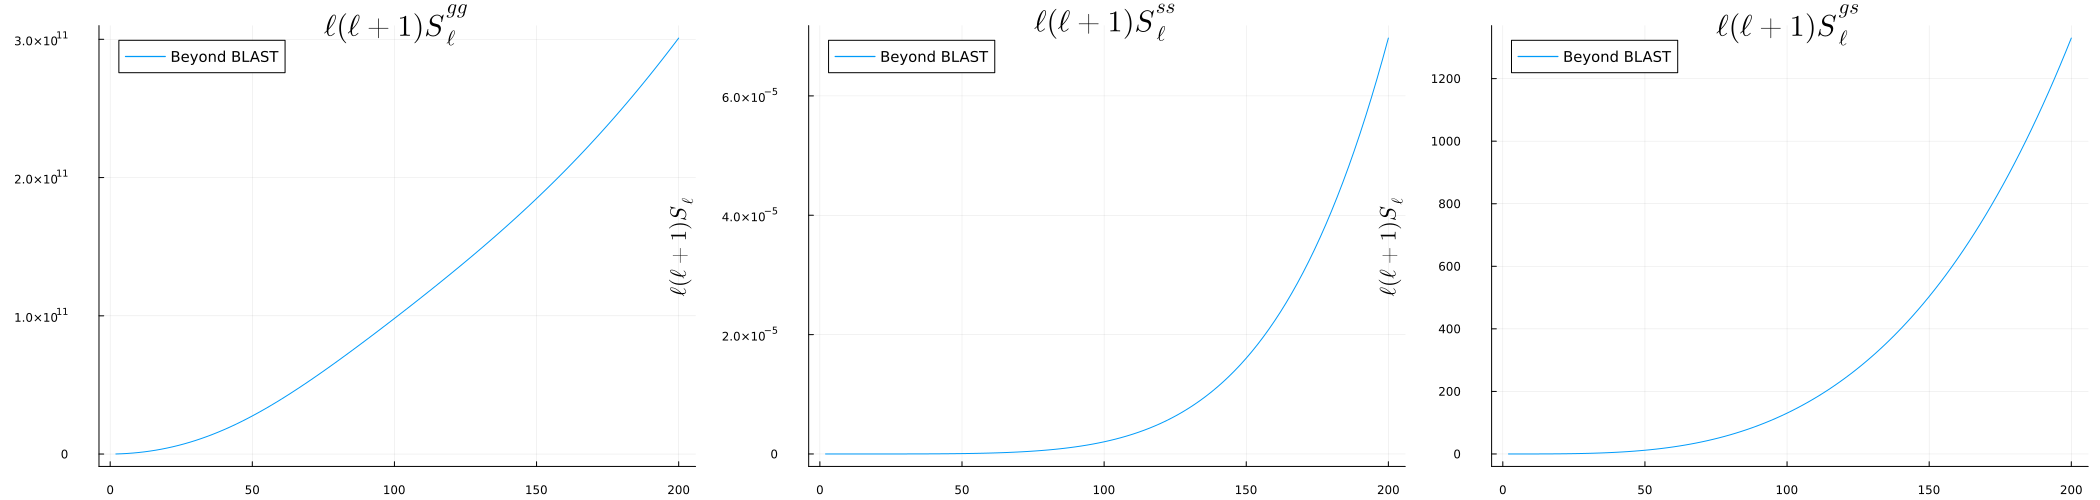

In [114]:
p1 = plot(
    ℓ,
    S_l_gg .* ℓ .* (ℓ .+ 1),
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"\ell(\ell+1)S_\ell^{gg}",
    markersize=4,
    size = (700, 500),
    titlefontsize=20,
    labelfontsize=15
)
p2 = plot(
    ℓ,
    S_l_ss .* ℓ .* (ℓ .+ 1),
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"\ell(\ell+1)S_\ell^{ss}",
    markersize=4,
    size = (700, 500),
    titlefontsize=20,
    labelfontsize=15
)
p3 = plot(
    ℓ,
    S_l_gs .* ℓ .* (ℓ .+ 1),
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"\ell(\ell+1)S_\ell^{gs}",
    markersize=4,
    size = (700, 500),
    titlefontsize=20,
    labelfontsize=15
) 
plot(p1, p2, p3, layout = (1, 3), size=(2100, 500), titlefontsize=20, legendfontsize=10)

In [ ]:
p1 = plot(ℓ, S_l_gg .* ℓ .* (ℓ .+ 1), label = L"N = $2^{15}+1$ with optimized $\tilde W$", xlabel = L"\ell", ylabel = L"\ell(\ell+1)S_\ell", title = L"\ell(\ell+1)S_\ell (gg)",
          markersize=4, size = (1400, 800), titlefontsize=20, labelfontsize=15, dpi = 200)
savefig(joinpath(output_dir, "plots/S_l_plot_gg_per_l.png"))
p2 = plot(ℓ, S_l_ss .* ℓ .* (ℓ .+ 1), label = L"N = $2^{15}+1$ with optimized $\tilde W$", xlabel = L"\ell", ylabel = L"\ell(\ell+1)S_\ell", title = L"\ell(\ell+1)S_\ell (ss)",
          markersize=4, size = (1400, 800), titlefontsize=20, labelfontsize=15, dpi = 200)
savefig(joinpath(output_dir, "plots/S_l_plot_ss_per_l.png"))
p3 = plot(ℓ, S_l_gs .* ℓ .* (ℓ .+ 1), label = L"N = $2^{15}+1$ with optimized $\tilde W$", xlabel = L"\ell", ylabel = L"\ell(\ell+1)S_\ell", title = L"\ell(\ell+1)S_\ell (gs)",
          markersize=4, size = (1400, 800), titlefontsize=20, labelfontsize=15, dpi = 200)
savefig(joinpath(output_dir, "plots/S_l_plot_gs_per_l.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_15_171150/plots/S_l_plot_gs_per_l.png"

In [110]:
params_run = Dict(
    "x_min" => x_min,
    "x_max" => x_max,
    "n_chi" => n_chi,
    "zmin" => zmin,
    "zmax" => zmax,
    "kmin" => kmin,
    "kmax" => kmax,
    "n_cheb" => n_cheb,
    "N" => N,
    "ℓ" => length(ℓ)
)

open(joinpath(output_dir, "config.json"), "w") do io
    JSON.print(io, params_run, 4) # Scrive il dizionario in formato JSON pulito
end

println("Data brought to safety in folder: ", output_dir)

Data brought to safety in folder: out/runs/run_2026_06_15_171150
